In [1]:
import os
import json
import re
import numpy as np
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack, csr_matrix


# ===== Класс для выделения числовых признаков =====
class NumericExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.keys = set()
        for row in X:
            if "numeric_parameters" in row:
                self.keys.update(row["numeric_parameters"].keys())
        self.keys = sorted(list(self.keys))
        return self

    def transform(self, X):
        result = []
        for row in X:
            values = []
            for key in self.keys:
                val = None
                if "numeric_parameters" in row and key in row["numeric_parameters"]:
                    val = row["numeric_parameters"][key].get("value")
                values.append(val if val is not None else np.nan)
            result.append(values)
        return np.nan_to_num(np.array(result))


# ===== Папка с JSON =====
data_dir = "epi_rash/preprocessed_medical_results"

# ===== Загрузка файлов =====
records = []
for fname in os.listdir(data_dir):
    if fname.endswith(".json"):
        with open(os.path.join(data_dir, fname), "r", encoding="utf-8") as f:
            try:
                records.append(json.load(f))
            except Exception as e:
                print(f"⚠️ Ошибка чтения {fname}: {e}")

print(f"Загружено файлов: {len(records)}")

# ===== Формируем X и y =====
X_records = []
y = []
for rec in records:
    diagnosis = rec.get("diagnosis", {}).get("diagnosis_text")
    if diagnosis is not None and diagnosis != "":
        y.append(diagnosis)
        X_records.append(rec)

print("После фильтрации с диагнозами:", len(X_records))

# ===== Подготовка текстов =====
texts = []
for rec in X_records:
    complaints = rec.get("complaints", {}).get("processed_text", "")
    disease_history = rec.get("disease_history", {}).get("processed_text", "")
    text = (complaints or "") + " " + (disease_history or "")
    text = re.sub(r"[^а-яА-Яa-zA-Z0-9 ]", " ", text)  # очищаем
    text = text.strip()
    if not text:
        text = "нет_данных"
    texts.append(text)

print("Пример текстов:", texts[:3])

# ===== TF-IDF =====
if all(t == "нет_данных" for t in texts):
    X_text = csr_matrix((len(texts), 1))  # фиктивный признак
else:
    vectorizer = TfidfVectorizer(max_features=500)
    X_text = vectorizer.fit_transform(texts)

# ===== Числовые признаки =====
num_extractor = NumericExtractor()
X_num = num_extractor.fit_transform(X_records)

# ===== Комбинация признаков =====
X = hstack([X_text, X_num]).tocsr()  # теперь можно индексировать

# ===== Обработка редких классов =====
counts = Counter(y)
valid_idx = [i for i, label in enumerate(y) if counts[label] > 1]

if len(valid_idx) < len(y):
    print(f"⚠️ Удалены классы с одним примером: {len(y) - len(valid_idx)}")
    X = X[valid_idx]
    y = [y[i] for i in valid_idx]

# ===== Обучение =====
if len(set(y)) < 2 or len(y) < 5:
    print("⚠️ Недостаточно данных для train/test, обучаем на всех примерах")
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X, y)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    print("\n=== Отчет по качеству ===")
    print(classification_report(y_test, y_pred, digits=4))


Загружено файлов: 2013
После фильтрации с диагнозами: 2010
Пример текстов: ['средний тяжести  лихорадка темперaтура 39 6 с  кашель мoкротой  одышка небольшой физическoть нагрузке  общий слабость  ломота теле  ноябрь 2020 перенести коронавирусный инфекцию  covid 19  лабораторный подтвержденную  39  потеря вкус обоняния  настоящий ухудшение начало март 2021 г  когда появиться боль горле  покашливание  07 03 2021 находиться аршане  быть интенсивный физический нагрузка  09 03 2021 ухудшилось  ломота теле  повышение температура 39 6  сухой кашель  пцр sars cov2 отрицательный  сохраняться лихорадка  кашель  появиться одышка  доставить при мный отделение гбуз иокб  выполнить мскт ангиография ла инфильтрация нижний доля оба легких  двухсторонний гидроторакс  медиастинальный лимфоаденопатия  гидроперикард  тэла определяется  сколиоз грудной отдел позвоночника  госпитализировать отделение пульмонологии   расти ла развиваться лася соответственно пол возрасту  сопутствовать хронический тонзилит  в

c:\Users\PC2\Desktop\Klukin\Epikriz_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC2\Desktop\Klukin\Epikriz_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC2\Desktop\Klukin\Epikriz_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [13]:
!pip freeze > requirements.txt

Загружено файлов: 2013
После фильтрации с диагнозами: 2010
Пример текстов: ['средний тяжести  лихорадка темперaтура 39 6 с  кашель мoкротой  одышка небольшой физическoть нагрузке  общий слабость  ломота теле  ноябрь 2020 перенести коронавирусный инфекцию  covid 19  лабораторный подтвержденную  39  потеря вкус обоняния  настоящий ухудшение начало март 2021 г  когда появиться боль горле  покашливание  07 03 2021 находиться аршане  быть интенсивный физический нагрузка  09 03 2021 ухудшилось  ломота теле  повышение температура 39 6  сухой кашель  пцр sars cov2 отрицательный  сохраняться лихорадка  кашель  появиться одышка  доставить при мный отделение гбуз иокб  выполнить мскт ангиография ла инфильтрация нижний доля оба легких  двухсторонний гидроторакс  медиастинальный лимфоаденопатия  гидроперикард  тэла определяется  сколиоз грудной отдел позвоночника  госпитализировать отделение пульмонологии   расти ла развиваться лася соответственно пол возрасту  сопутствовать хронический тонзилит  в

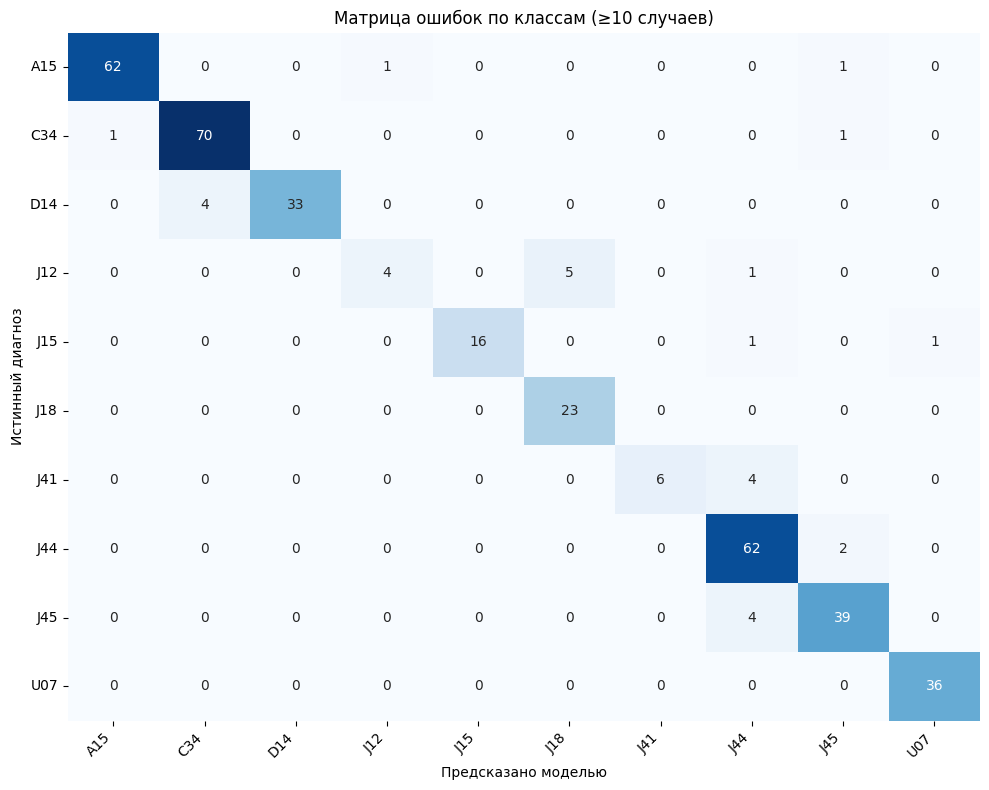

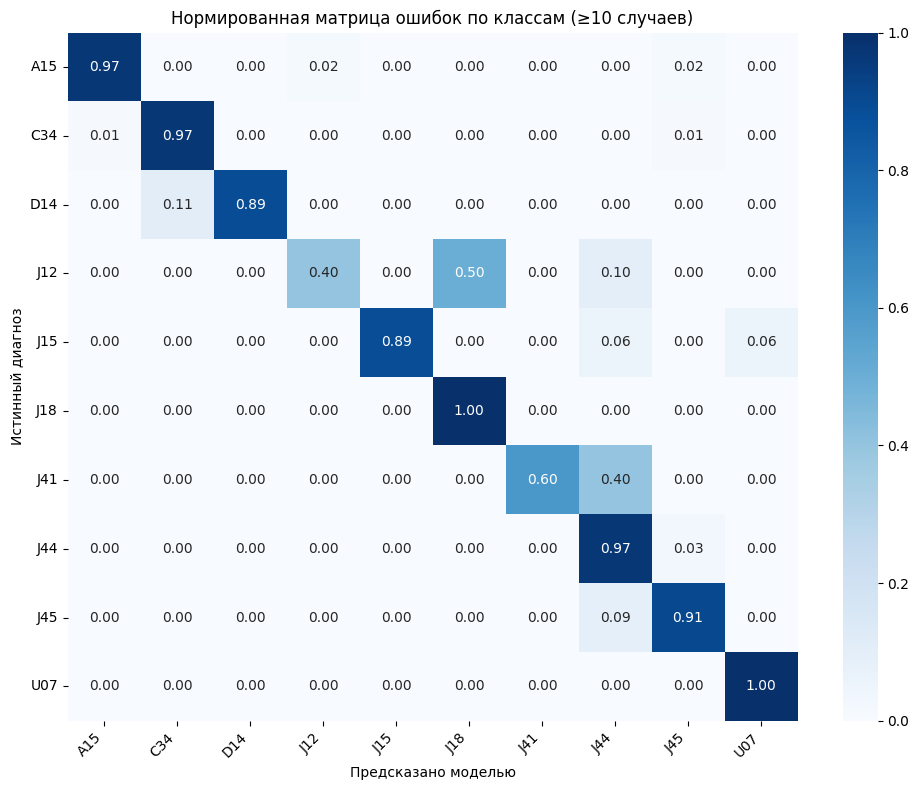


=== Расшифровка используемых диагнозов ===
A15: Туберкулёз органов дыхания
C34: Злокачественные новообразования лёгких
D14: Доброкачественные опухоли дыхательных органов
J12: Вирусная пневмония
J15: Бактериальная пневмония
J18: Пневмония неуточнённая
J41: Простой хронический бронхит
J44: Хроническая обструктивная болезнь лёгких (ХОБЛ)
J45: Бронхиальная астма
U07: COVID-19


In [12]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack, csr_matrix


# ===== Группировка ICD-10 по укрупнённым классам =====
diagnosis_groups = {
    "A15": ["A15", "A15.0", "A15.1", "A15.2", "A16", "A16.0", "A16.1"],
    "C34": ["C34", "C34.0", "C34.1", "C34.2", "C34.3", "C34.8"],
    "D14": ["D14.3"],
    "D86": ["D86.0", "D86.2"],
    "I26": ["I26.0", "I26.9"],
    "I27": ["I27.2", "I27.8"],
    "J12": ["J12.8"],
    "J15": ["J15.8"],
    "J18": ["J18", "J18.8", "J18.9"],
    "J20": ["J20.2", "J20.9"],
    "J41": ["J41.0", "J41.1"],
    "J44": ["J44.1", "J44.8"],
    "J45": ["J45.0", "J45.1", "J45.8", "J45.9"],
    "U07": ["U07.1", "U07.2"]
}

# ===== Расшифровка укрупнённых диагнозов =====
diagnosis_descriptions = {
    "A15": "Туберкулёз органов дыхания",
    "C34": "Злокачественные новообразования лёгких",
    "D14": "Доброкачественные опухоли дыхательных органов",
    "D86": "Саркоидоз органов дыхания",
    "I26": "Тромбоэмболия лёгочной артерии (ТЭЛА)",
    "I27": "Лёгочная гипертензия",
    "J12": "Вирусная пневмония",
    "J15": "Бактериальная пневмония",
    "J18": "Пневмония неуточнённая",
    "J20": "Острый бронхит",
    "J41": "Простой хронический бронхит",
    "J44": "Хроническая обструктивная болезнь лёгких (ХОБЛ)",
    "J45": "Бронхиальная астма",
    "U07": "COVID-19"
}


# ===== Унификация кодов диагнозов =====
def unify_diagnosis(code: str) -> str:
    for group, subcodes in diagnosis_groups.items():
        if code in subcodes:
            return group
    return code


# ===== Извлечение числовых признаков =====
class NumericExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.keys = set()
        for row in X:
            if "numeric_parameters" in row:
                self.keys.update(row["numeric_parameters"].keys())
        self.keys = sorted(list(self.keys))
        return self

    def transform(self, X):
        result = []
        for row in X:
            values = []
            for key in self.keys:
                val = None
                if "numeric_parameters" in row and key in row["numeric_parameters"]:
                    val = row["numeric_parameters"][key].get("value")
                values.append(val if val is not None else np.nan)
            result.append(values)
        return np.nan_to_num(np.array(result))


# ===== Основная директория =====
data_dir = "epi_rash/preprocessed_medical_results"

# ===== Загрузка данных =====
records = []
for fname in os.listdir(data_dir):
    if fname.endswith(".json"):
        with open(os.path.join(data_dir, fname), "r", encoding="utf-8") as f:
            try:
                records.append(json.load(f))
            except Exception as e:
                print(f"⚠️ Ошибка чтения {fname}: {e}")

print(f"Загружено файлов: {len(records)}")

# ===== Формирование X и y =====
X_records = []
y = []
for rec in records:
    diagnosis = rec.get("diagnosis", {}).get("diagnosis_text")
    if diagnosis:
        unified = unify_diagnosis(diagnosis)
        y.append(unified)
        X_records.append(rec)

print("После фильтрации с диагнозами:", len(X_records))

# ===== Подготовка текстов =====
texts = []
for rec in X_records:
    complaints = rec.get("complaints", {}).get("processed_text", "")
    disease_history = rec.get("disease_history", {}).get("processed_text", "")
    text = (complaints or "") + " " + (disease_history or "")
    text = re.sub(r"[^а-яА-Яa-zA-Z0-9 ]", " ", text)
    text = text.strip()
    if not text:
        text = "нет_данных"
    texts.append(text)

print("Пример текстов:", texts[:3])

# ===== TF-IDF =====
if all(t == "нет_данных" for t in texts):
    X_text = csr_matrix((len(texts), 1))
else:
    vectorizer = TfidfVectorizer(max_features=500)
    X_text = vectorizer.fit_transform(texts)

# ===== Числовые признаки =====
num_extractor = NumericExtractor()
X_num = num_extractor.fit_transform(X_records)

# ===== Комбинация признаков =====
X = hstack([X_text, X_num]).tocsr()

# ===== Фильтрация редких классов (меньше 10 случаев) =====
min_samples = 10
counts = Counter(y)
valid_idx = [i for i, label in enumerate(y) if counts[label] >= min_samples]

if len(valid_idx) < len(y):
    removed = len(y) - len(valid_idx)
    print(f"⚠️ Удалены классы с количеством < {min_samples} случаев: {removed}")
    X = X[valid_idx]
    y = [y[i] for i in valid_idx]

# ===== Повторная фильтрация после разбиения =====
def filter_rare_classes(X_data, y_data, threshold):
    counts = Counter(y_data)
    valid = [i for i, label in enumerate(y_data) if counts[label] >= threshold]
    return X_data[valid], [y_data[i] for i in valid]


# ===== Обучение =====
if len(set(y)) < 2 or len(y) < 20:
    print("⚠️ Недостаточно данных для разделения, обучение на всей выборке.")
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X, y)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Удаляем редкие классы из train/test после стратификации
    X_train, y_train = filter_rare_classes(X_train, y_train, min_samples)
    X_test, y_test = filter_rare_classes(X_test, y_test, min_samples)

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # ===== Отчёт =====
    print(f"\n=== Отчёт по качеству (только классы ≥{min_samples} случаев) ===")
    print(classification_report(y_test, y_pred, digits=4))

    # ===== Матрица ошибок =====
    unified_labels = sorted(list(set(y_test)))
    cm = confusion_matrix(y_test, y_pred, labels=unified_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=unified_labels,
        yticklabels=unified_labels,
        cmap="Blues",
        cbar=False
    )
    plt.title(f"Матрица ошибок по классам (≥{min_samples} случаев)")
    plt.xlabel("Предсказано моделью")
    plt.ylabel("Истинный диагноз")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ===== Матрица ошибок (нормированная) =====
    cm_norm = confusion_matrix(y_test, y_pred, labels=unified_labels, normalize="true")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        xticklabels=unified_labels,
        yticklabels=unified_labels,
        cmap="Blues",
        cbar=True
    )
    plt.title(f"Нормированная матрица ошибок по классам (≥{min_samples} случаев)")
    plt.xlabel("Предсказано моделью")
    plt.ylabel("Истинный диагноз")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ===== Расшифровка =====
    print("\n=== Расшифровка используемых диагнозов ===")
    for code in unified_labels:
        print(f"{code}: {diagnosis_descriptions.get(code, 'Неизвестное заболевание')}")
